In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow import keras
import ast
from sklearn.metrics import r2_score, mean_squared_error
from tensorflow import keras


In [2]:
# -------------------------
# CONFIGURAÇÕES GERAIS
# -------------------------
PREDICTORS = ["PwmD", "PwmE"]
TARGET = ["Wd", "We"]
INPUT_SIZE = len(PREDICTORS)  
OUTPUT_SIZE = len(TARGET) 
TIME_STEPS = 7
NDATASETS = 4  # ajuste se houver mais datasets

In [3]:
# -------------------------
# LEITURA DOS DATASETS
# -------------------------
Datasets = []
for i in range(NDATASETS):
    Dataset = pd.read_csv(f"../Dados/TestData/Data{i + 1}.csv")
    Dataset.index = (np.arange(0, len(Dataset)) * 0.07).round(5)
    Datasets.append(Dataset)
    print(f"++++++++++++++++++++ Dataset {i+1} +++++++++++++++++++++++")
    print(Dataset.head())

++++++++++++++++++++ Dataset 1 +++++++++++++++++++++++
        X    Y  Theta   Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.0  0.0  -0.00   0.00  -0.00   0.00
0.07  0.0  0.7    0.0  0.0  0.0   3.28   3.28  -0.00   0.00
0.14  0.0  0.7    0.0  0.0  0.0   3.28   3.28  49.25  49.25
0.21  0.0  0.7    0.0  0.0  0.0   3.28   3.28  49.25  49.25
0.28  0.0  0.7    0.0  0.0  0.0   3.28   3.28  68.95  68.95
++++++++++++++++++++ Dataset 2 +++++++++++++++++++++++
        X    Y  Theta   Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.0  0.0  -0.00   0.00  -0.00   0.00
0.07  0.0  0.7    0.0  0.0  0.0   3.02   3.02  -0.00   0.00
0.14  0.0  0.7    0.0  0.0  0.0   3.02   3.02  45.32  45.32
0.21  0.0  0.7    0.0  0.0  0.0   3.02   3.02  45.32  45.32
0.28  0.0  0.7    0.0  0.0  0.0   3.02   3.02  63.44  63.44
++++++++++++++++++++ Dataset 3 +++++++++++++++++++++++
        X    Y  Theta   Wd   We  WdRef  WeRef   PwmD   PwmE
0.00  0.0  0.7    0.0  0.0  0.0  -0.00   0.00  -0.00   

In [4]:
# -------------------------
# NORMALIZAÇÃO
# -------------------------
NormDatasets = []
SCALER = StandardScaler()
OUT_SCALER = StandardScaler()

TrainDataset = pd.read_csv(f"../Dados/Data1.csv")
SCALER.fit(TrainDataset[PREDICTORS])
OUT_SCALER.fit(TrainDataset[TARGET])

for i in range(NDATASETS):
    CurrentTestDataset = Datasets[i].copy()

    CurrentTestDataset[PREDICTORS] = SCALER.transform(CurrentTestDataset[PREDICTORS])
    CurrentTestDataset[TARGET] = OUT_SCALER.transform(CurrentTestDataset[TARGET])

    NormDatasets.append(CurrentTestDataset)
    print(f"++++++++++++++++++++ Dataset Normalizado {i+1} +++++++++++++++++++++++")
    print(NormDatasets[i].head())


++++++++++++++++++++ Dataset Normalizado 1 +++++++++++++++++++++++
        X    Y  Theta        Wd       We  WdRef  WeRef      PwmD      PwmE
0.00  0.0  0.7    0.0  0.107454  0.09236  -0.00   0.00  0.464323  0.399504
0.07  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  0.464323  0.399504
0.14  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  1.136042  0.929853
0.21  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  1.136042  0.929853
0.28  0.0  0.7    0.0  0.107454  0.09236   3.28   3.28  1.404730  1.141992
++++++++++++++++++++ Dataset Normalizado 2 +++++++++++++++++++++++
        X    Y  Theta        Wd       We  WdRef  WeRef      PwmD      PwmE
0.00  0.0  0.7    0.0  0.107454  0.09236  -0.00   0.00  0.464323  0.399504
0.07  0.0  0.7    0.0  0.107454  0.09236   3.02   3.02  0.464323  0.399504
0.14  0.0  0.7    0.0  0.107454  0.09236   3.02   3.02  1.082441  0.887533
0.21  0.0  0.7    0.0  0.107454  0.09236   3.02   3.02  1.082441  0.887533
0.28  0.0  0.7    0.0  0.107454  0.09236 

In [5]:
# -------------------------
# FUNÇÃO PARA CRIAR SEQUÊNCIAS
# -------------------------
def CreateSequences(input_data, target_data, timesteps):
    X_seq, Y_seq = [], []
    for i in range(timesteps, len(input_data)):
        X_seq.append(input_data.iloc[i - timesteps:i].values)
        Y_seq.append(target_data.iloc[i].values)
    return np.array(X_seq), np.array(Y_seq)

# Odometria 

- R = 0.034    Raio da roda (m)
- L = 0.147/2  Distância entre rodas (m)
- T = 0.07     Período de amostragem (s)

- $x_{k+1} = x_k + \frac{R . T}{2} . (\phi_d[k] + \phi_e[k]) \cos(\theta_k)$

- $  y_{k+1} = y_k + \frac{R . T}{2} . (\phi_d[k] + \phi_e[k]) \sin(\theta_k)  $

- $ \theta_{k+1} = \theta_k + \frac{R . T}{2L} . (\phi_d[k] - \phi_e[k]) $



In [6]:
R = 0.032   
L = 0.124/2  
T = 0.07   

def Odometry(Wd, We, x0=0, y0=0.7, theta0=0):

    n = len(Wd)
    X_est, Y_est, Theta_est = [x0], [y0], [theta0]

    for k in range(n - 1):
        theta_k = Theta_est[-1]

        # Cinemática diferencial
        x_next = X_est[-1] + (R * T / 2) * (np.cos(theta_k) * (Wd[k] + We[k]))
        y_next = Y_est[-1] + (R * T / 2) * (np.sin(theta_k) * (Wd[k] + We[k]))
        theta_next = Theta_est[-1] + (R * T / (2 * L)) * (Wd[k] - We[k])

        X_est.append(x_next)
        Y_est.append(y_next)
        Theta_est.append(theta_next)

    return np.array(X_est), np.array(Y_est), np.array(Theta_est)



In [7]:
import matplotlib.pyplot as plt
import numpy as np

def PlotTrajectoryEvolution(X_true, Y_true, Theta_true, X_est, Y_est, Theta_est, title):
    """
    Exibe 3 gráficos discretos (X, Y, Θ) em função do tempo (ou iteração k).
    Cada gráfico mostra amostras reais e estimadas.
    """
    k = np.arange(len(X_true))
    time = (k * T).round(5)

    fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    # --- X ---
    axs[0].scatter(time, X_true, marker='o', s=15, label='X verdadeiro', color='blue', alpha=0.7)
    axs[0].scatter(time, X_est, marker='x', s=15, label='X estimado', color='red', alpha=0.7)
    axs[0].set_ylabel('X [m]')
    axs[0].legend()
    axs[0].grid(True)

    # --- Y ---
    axs[1].scatter(time, Y_true, marker='o', s=15, label='Y verdadeiro', color='blue', alpha=0.7)
    axs[1].scatter(time, Y_est, marker='x', s=15, label='Y estimado', color='red', alpha=0.7)
    axs[1].set_ylabel('Y [m]')
    axs[1].legend()
    axs[1].grid(True)

    # --- Theta ---
    axs[2].scatter(time, Theta_true, marker='o', s=15, label=r'$\theta$ verdadeiro', color='blue', alpha=0.7)
    axs[2].scatter(time, Theta_est, marker='x', s=15, label=r'$\theta$ estimado', color='red', alpha=0.7)
    axs[2].set_xlabel('Tempo [s]')
    axs[2].set_ylabel(r'$\theta$ [rad]')
    axs[2].legend()
    axs[2].grid(True)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


In [8]:
# -------------------------
# SELECIONA OS 5 MELHORES MODELOS
# -------------------------
SORT_BY = "R2_Test_We"  # coluna usada para classificar os modelos

results_df = pd.read_excel("./resultados.xlsx")
results_df = results_df.sort_values(SORT_BY, ascending=False)
ModelsConfs = results_df.head(4).reset_index(drop=True)

print("+++++ Top 4 modelos selecionados +++++")
display(ModelsConfs)

+++++ Top 4 modelos selecionados +++++


,model,Neurons,R2_Train_Wd,MSE_Train_Wd,R2_Val_Wd,MSE_Val_Wd,R2_Test_Wd,MSE_Test_Wd,R2_Train_We,MSE_Train_We,R2_Val_We,MSE_Val_We,R2_Test_We,MSE_Test_We,W0,Wf
0,model_16_9,16,[0.92318624011083],[0.286989926150127],[0.9533673592939406],[0.19873868735248865],[0.934727899865458],[0.3405269755258593],[0.9409741196860679],[0.2124870573463732],[0.9501154162133543],[0.21126469015256977],[0.9179926502069188],[0.4385364863992883],"[[[-0.06440000236034393, -0.027699999511241913...","[[[0.04610000178217888, 0.03739999979734421, -..."
1,model_16_0,16,[0.9219070101830469],[0.2917693576352304],[0.9363254784329212],[0.27136766527559353],[0.9097057729196542],[0.47106834300929273],[0.9449686836231828],[0.19810704078643185],[0.9512541166435255],[0.206442214443729],[0.9147390277371099],[0.4559353191817149],"[[[0.003599999938160181, -0.017000000923871994...","[[[0.09470000118017197, -0.03920000046491623, ..."
2,model_12_1,12,[0.9232748784391025],[0.2866587575245875],[0.9525947682397509],[0.20203131092355728],[0.9317987493001458],[0.3558084630344525],[0.9377393499041314],[0.22413189361990224],[0.9499138775124751],[0.2121182206015173],[0.9126206323308305],[0.46726349501739545],"[[[-0.020999999716877937, 0.13940000534057617,...","[[[-0.133200004696846, 0.1818999946117401, -0...."
3,model_5_9,5,[0.9229356303521097],[0.2879275709227432],[0.9457426487514847],[0.2308740917073079],[0.9302354048663175],[0.3632444385155329],[0.9342976563556197],[0.23618995944941035],[0.9500726987184065],[0.21117192946453736],[0.9110286697078315],[0.4748168661307898],"[[[-0.020800000056624413, 0.07909999787807465,...","[[[0.2046000063419342, 0.5429999828338623, 0.3..."




===== Avaliando Dataset 1 =====
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

===== model_16_9 =====
R2_X = -0.7674, MSE_X = 0.179250
R2_Y = -8.5558, MSE_Y = 0.761390
R2_Theta = -47.0207, MSE_Theta = 13.533815


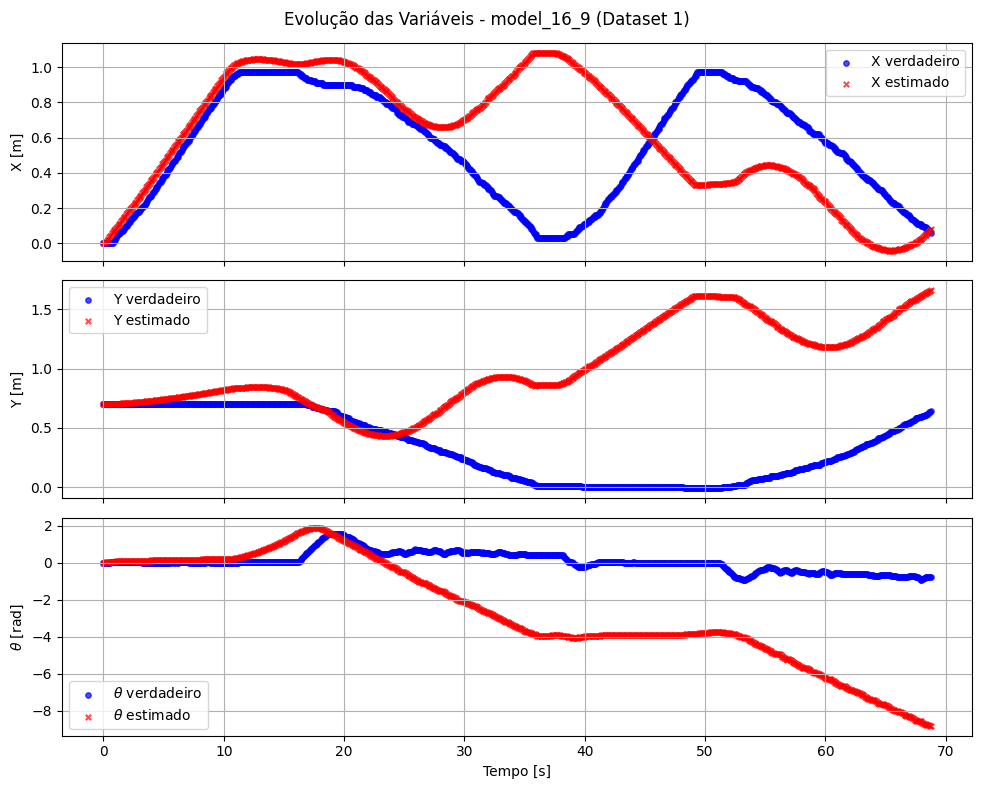

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

===== model_16_0 =====
R2_X = -25.8252, MSE_X = 2.720612
R2_Y = -0.4994, MSE_Y = 0.119474
R2_Theta = -242.0270, MSE_Theta = 68.492945


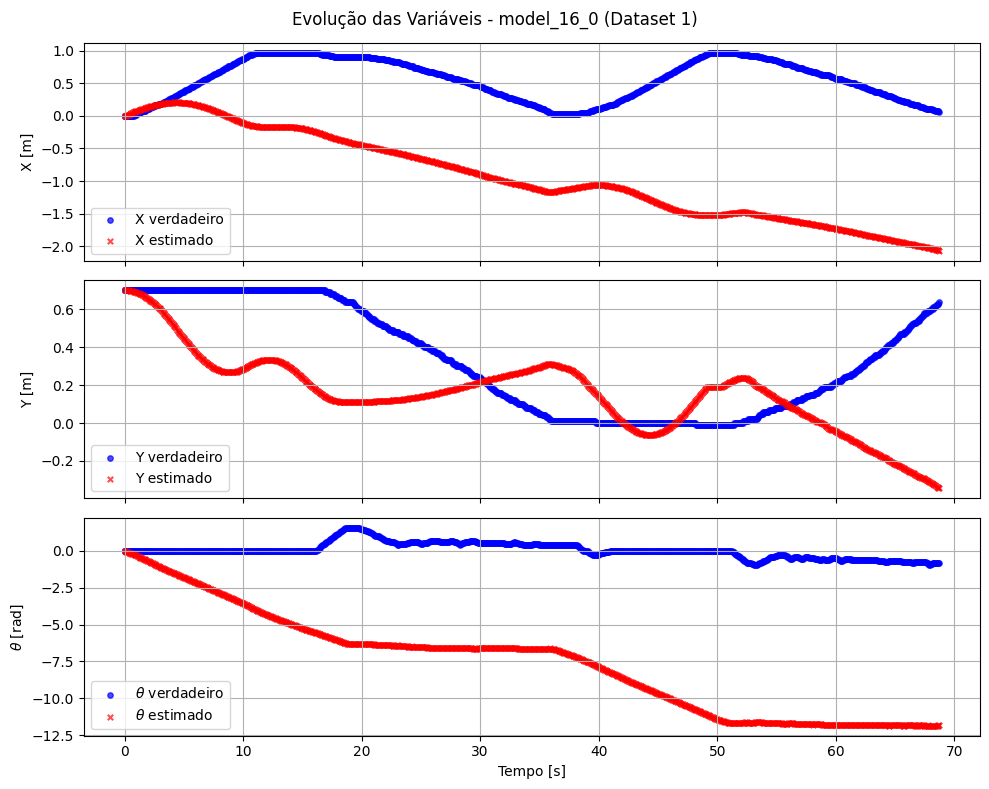

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

===== model_12_1 =====
R2_X = -3.0232, MSE_X = 0.408032
R2_Y = -2.1608, MSE_Y = 0.251852
R2_Theta = -6.2616, MSE_Theta = 2.046551


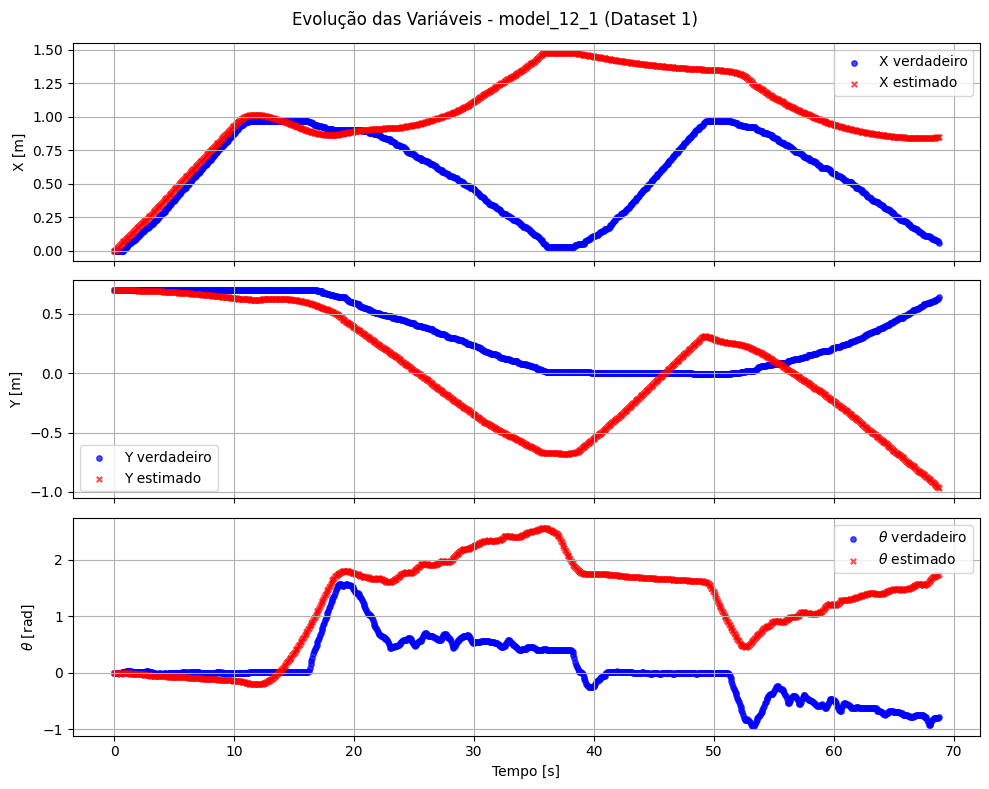

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

===== model_5_9 =====
R2_X = 0.4300, MSE_X = 0.057809
R2_Y = 0.1990, MSE_Y = 0.063821
R2_Theta = -1.9707, MSE_Theta = 0.837249


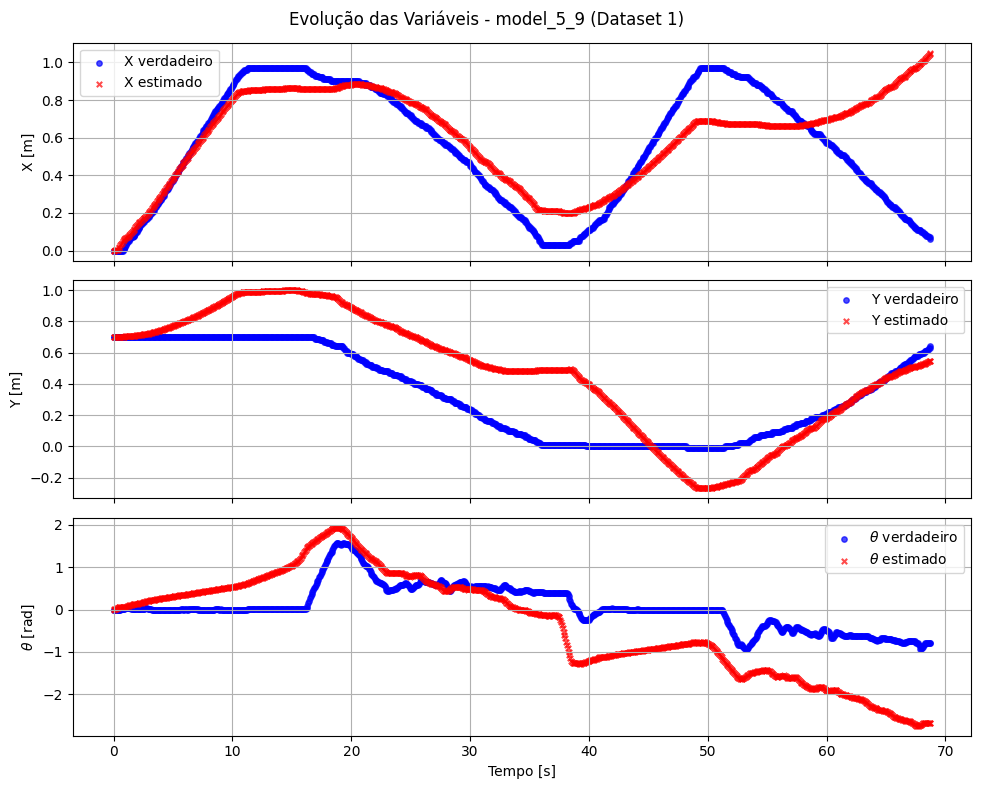



===== Avaliando Dataset 2 =====
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

===== model_16_9 =====
R2_X = -47.4108, MSE_X = 4.511425
R2_Y = -13.8166, MSE_Y = 0.775330
R2_Theta = -5.6786, MSE_Theta = 19.729561


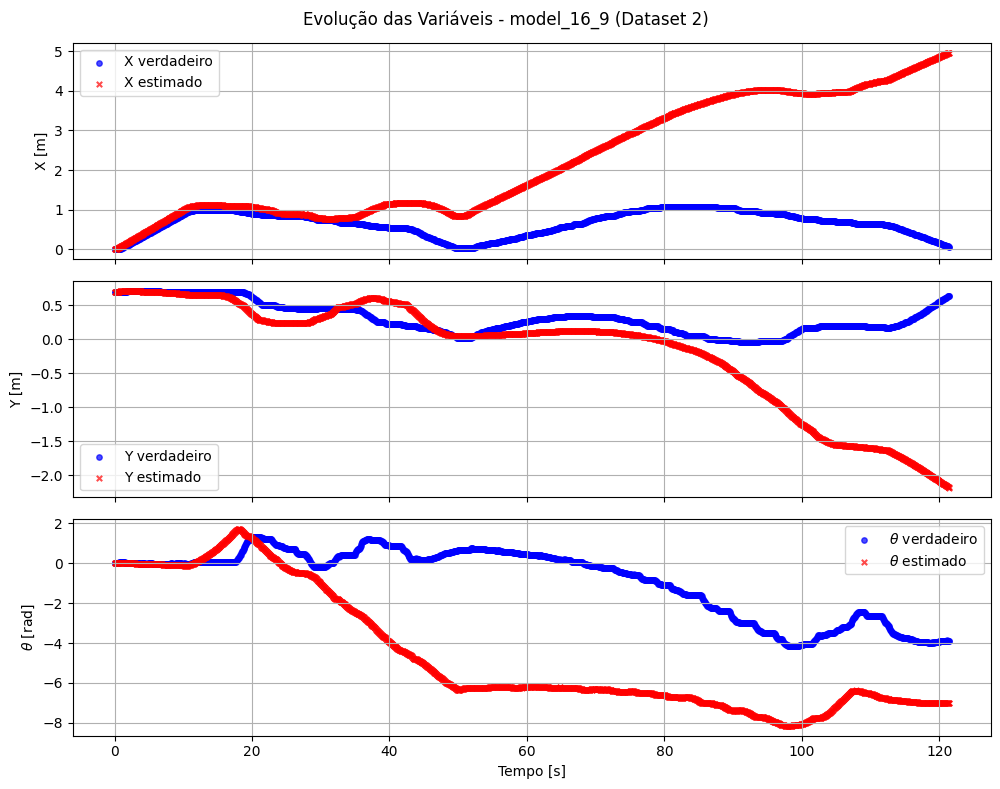

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

===== model_16_0 =====
R2_X = -27.4192, MSE_X = 2.648400
R2_Y = -4.0537, MSE_Y = 0.264453
R2_Theta = -90.7687, MSE_Theta = 271.097255


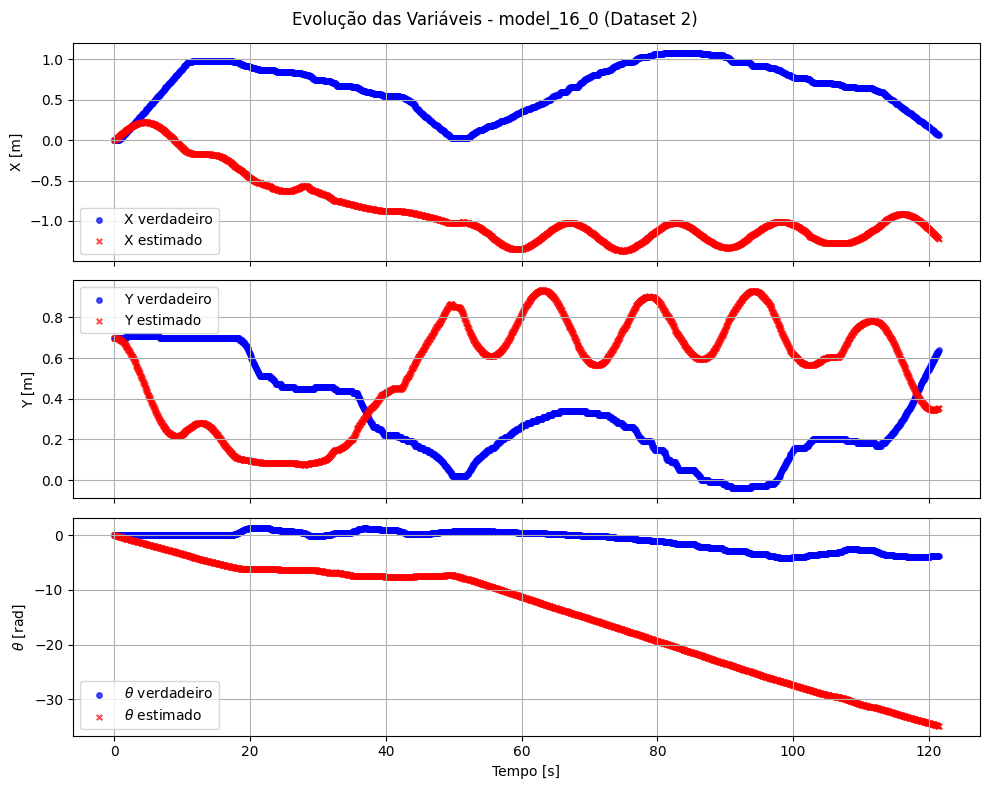

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

===== model_12_1 =====
R2_X = -1.7294, MSE_X = 0.254357
R2_Y = -7.1989, MSE_Y = 0.429035
R2_Theta = 0.0400, MSE_Theta = 2.835911


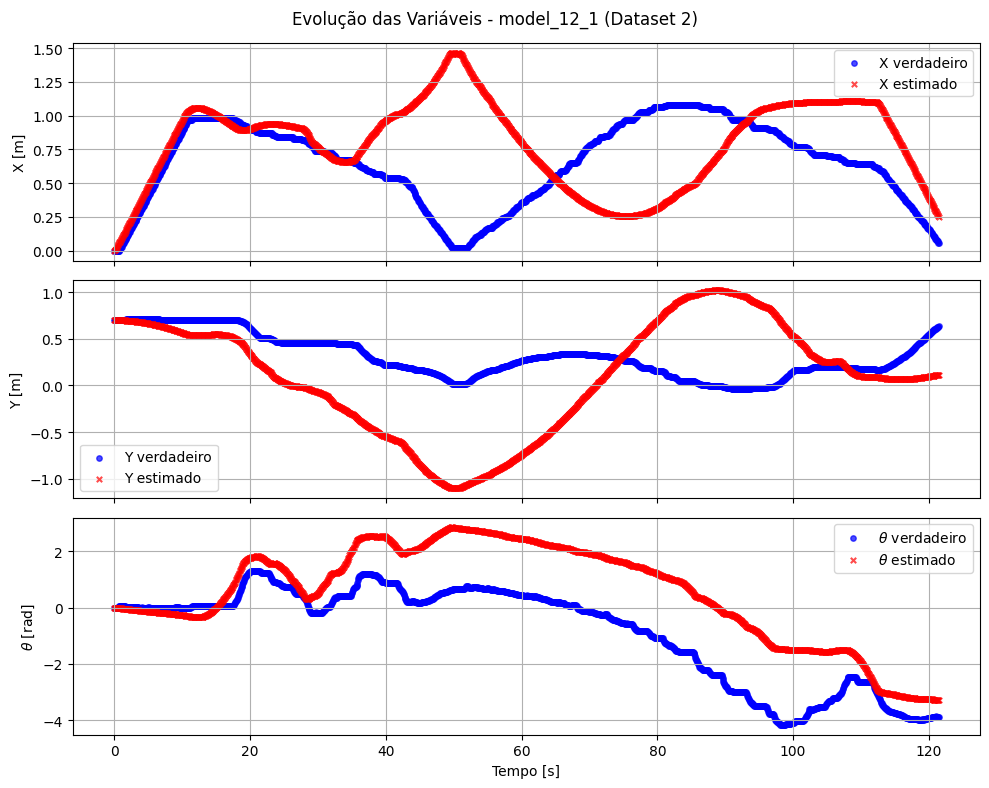

55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

===== model_5_9 =====
R2_X = -3.7251, MSE_X = 0.440331
R2_Y = -19.7388, MSE_Y = 1.085233
R2_Theta = 0.2965, MSE_Theta = 2.078380


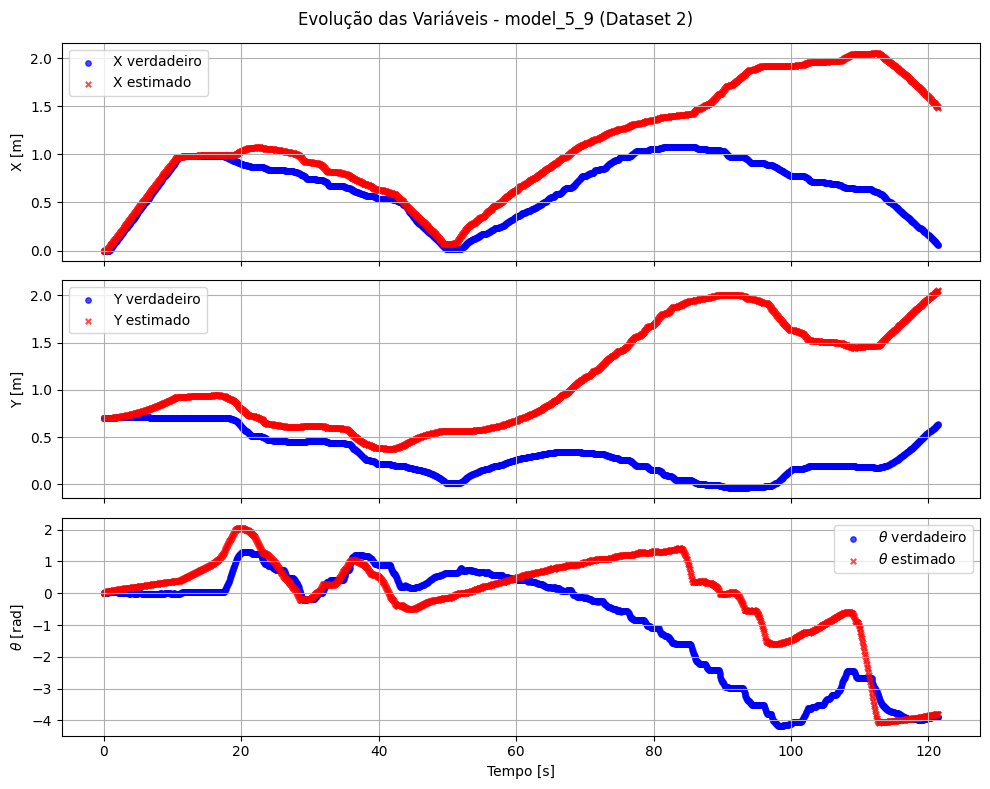



===== Avaliando Dataset 3 =====
41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

===== model_16_9 =====
R2_X = -1.1138, MSE_X = 0.167989
R2_Y = -0.6568, MSE_Y = 0.098176
R2_Theta = -250.4445, MSE_Theta = 100.393441


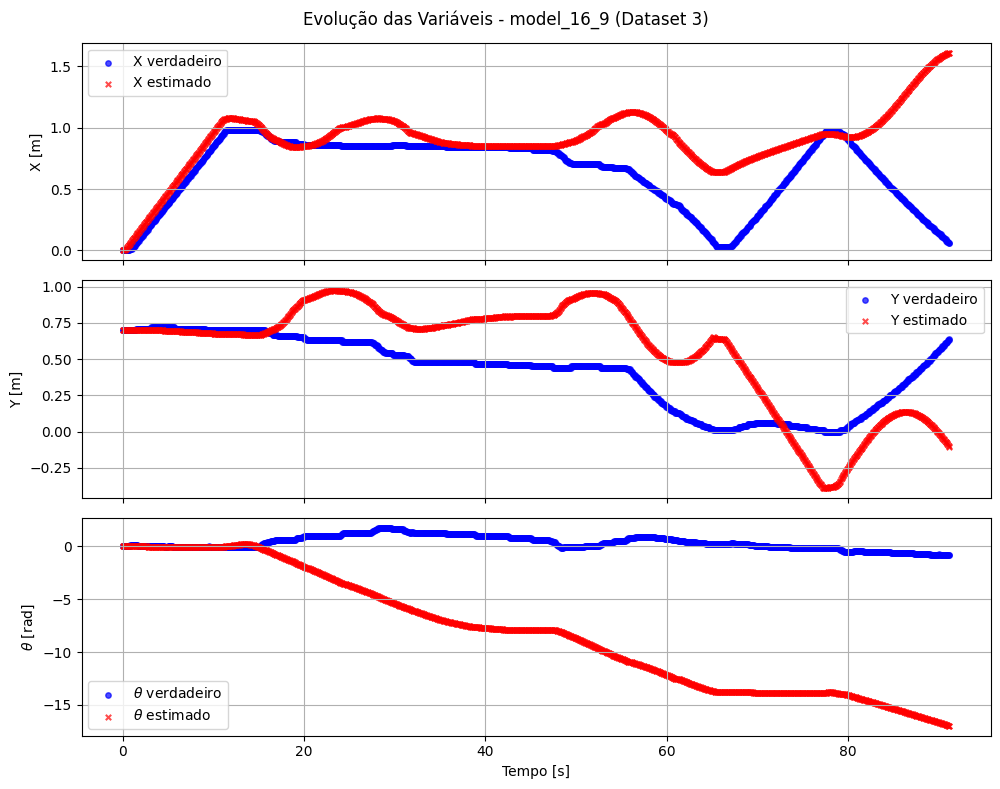

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

===== model_16_0 =====
R2_X = -11.8963, MSE_X = 1.024885
R2_Y = -1.1730, MSE_Y = 0.128766
R2_Theta = -224.0272, MSE_Theta = 89.845895


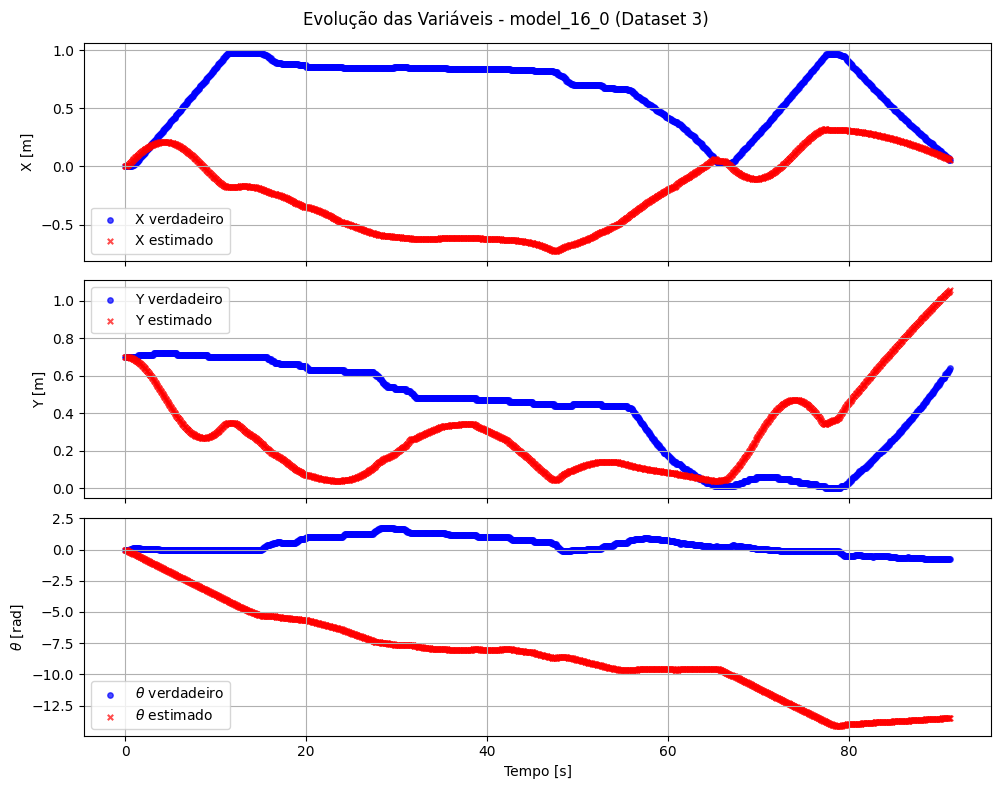

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step

===== model_12_1 =====
R2_X = 0.2155, MSE_X = 0.062344
R2_Y = -1.1979, MSE_Y = 0.130241
R2_Theta = -2.4183, MSE_Theta = 1.364823


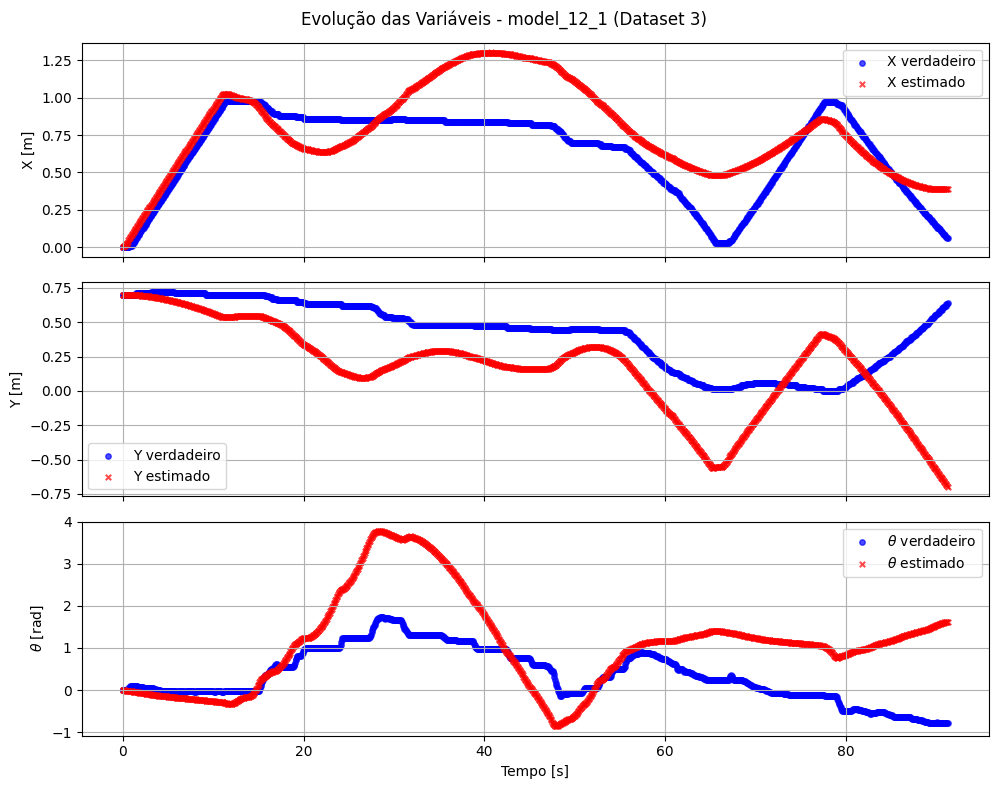

41/41 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

===== model_5_9 =====
R2_X = -1.4510, MSE_X = 0.194784
R2_Y = -4.0764, MSE_Y = 0.300811
R2_Theta = -5.9276, MSE_Theta = 2.765966


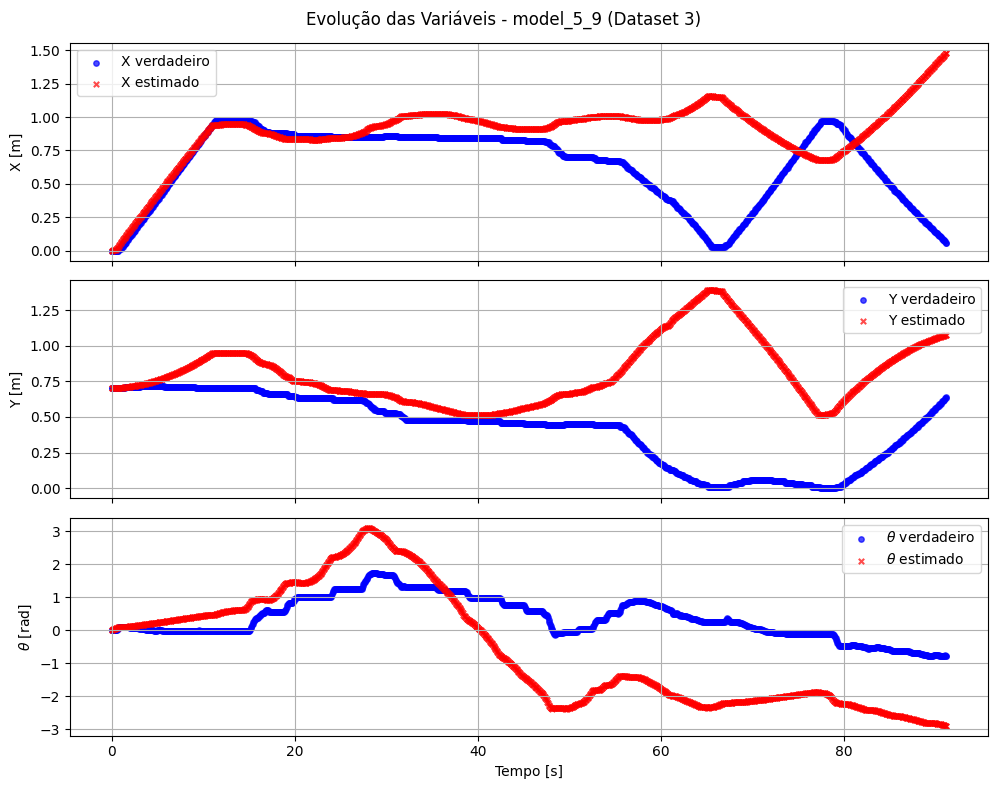



===== Avaliando Dataset 4 =====
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

===== model_16_9 =====
R2_X = -0.7195, MSE_X = 0.159514
R2_Y = -3.3714, MSE_Y = 0.323469
R2_Theta = -141.6864, MSE_Theta = 47.293057


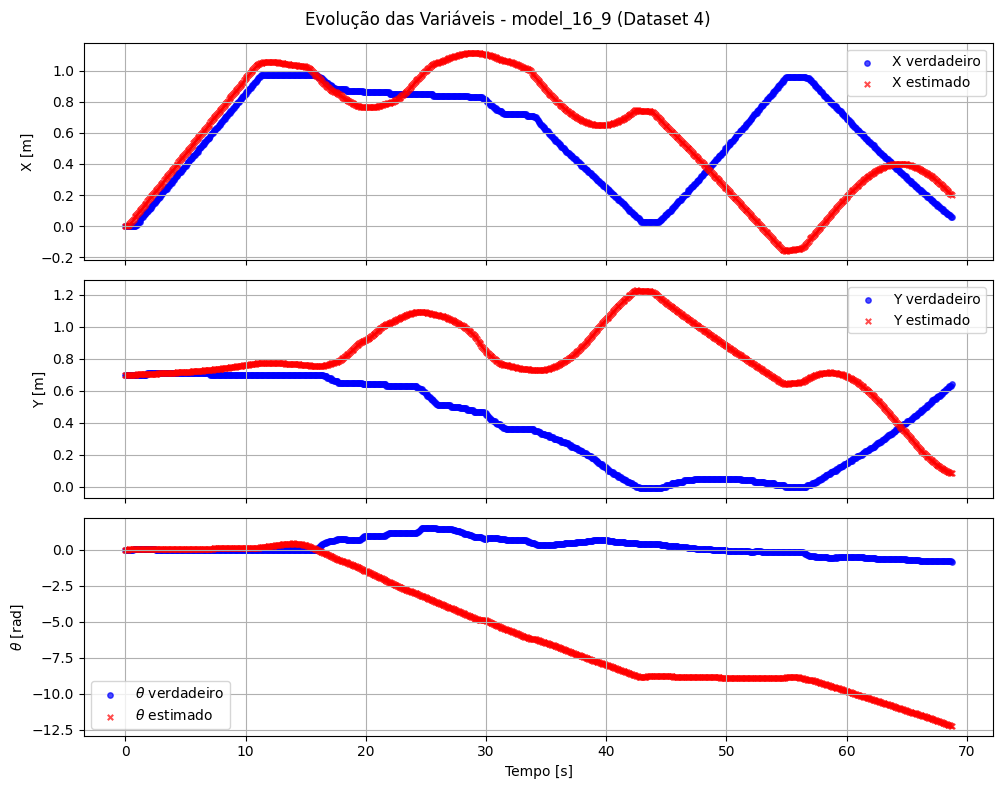

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

===== model_16_0 =====
R2_X = -26.9107, MSE_X = 2.589183
R2_Y = -1.6977, MSE_Y = 0.199620
R2_Theta = -173.2229, MSE_Theta = 57.745754


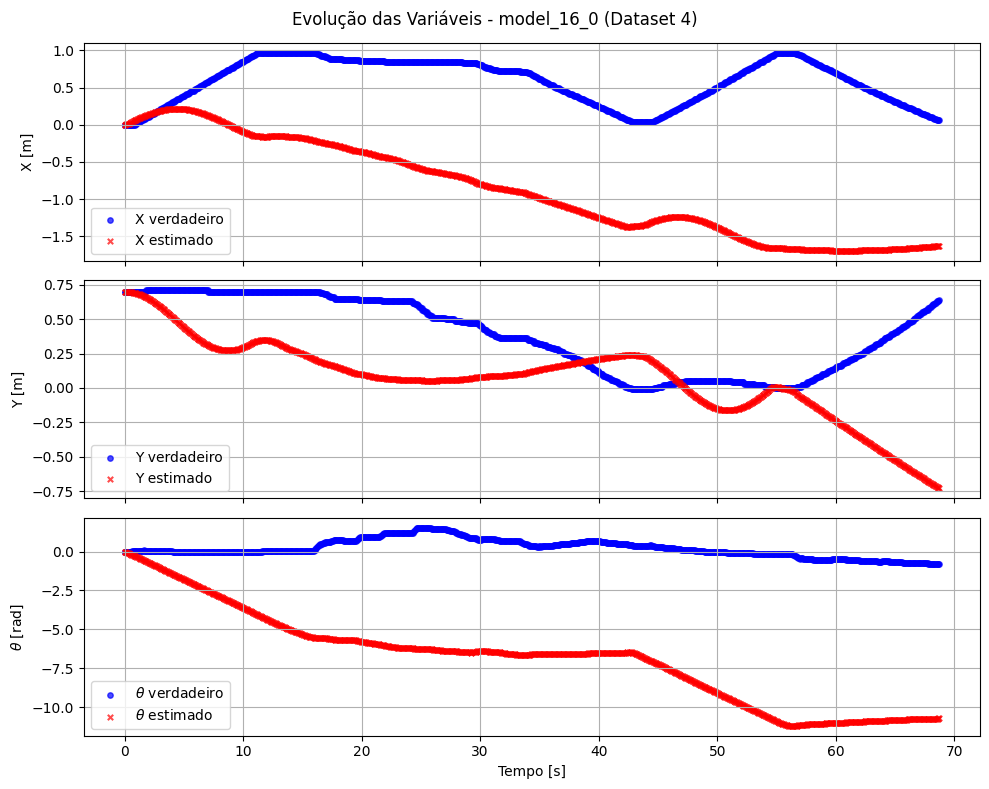

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

===== model_12_1 =====
R2_X = -8.9588, MSE_X = 0.923843
R2_Y = -2.8695, MSE_Y = 0.286331
R2_Theta = -14.1164, MSE_Theta = 5.010296


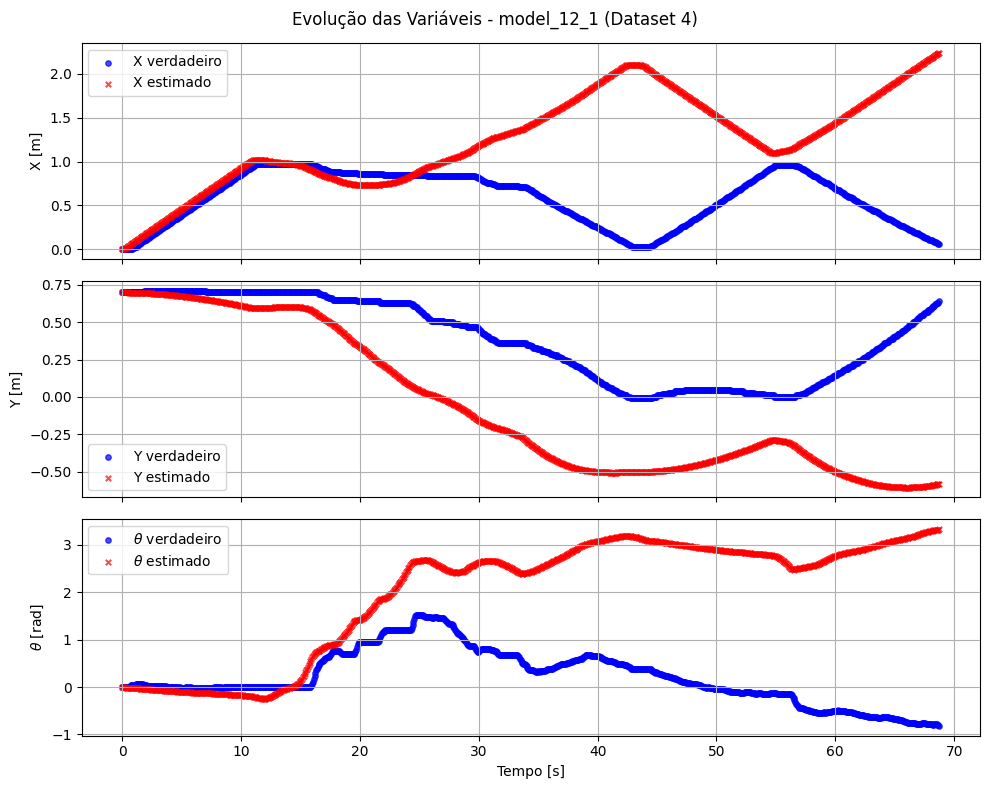

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

===== model_5_9 =====
R2_X = -0.2065, MSE_X = 0.111920
R2_Y = 0.2630, MSE_Y = 0.054538
R2_Theta = -0.9630, MSE_Theta = 0.650635


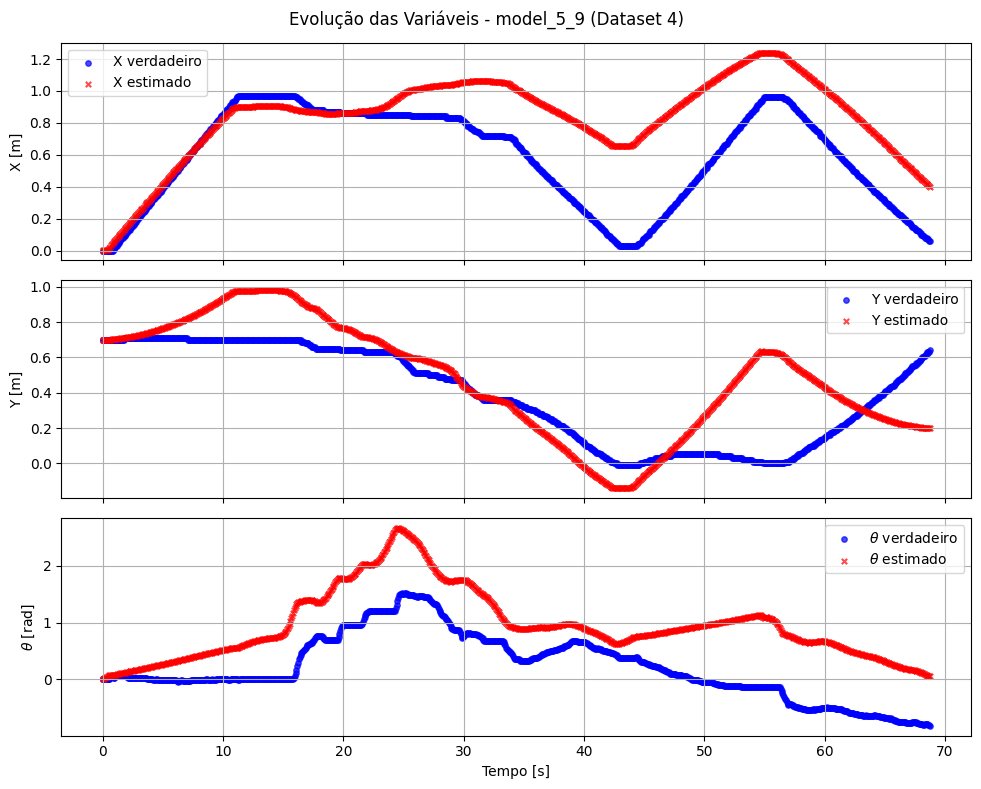

In [9]:
import pandas as pd
from sklearn.metrics import r2_score, mean_squared_error

# -------------------------
# RECONSTRUÇÃO E AVALIAÇÃO
# -------------------------

results = []  # lista para armazenar métricas

# Correção: iteração simultânea deve usar zip()
for i, (NormDataset, Dataset) in enumerate(zip(NormDatasets, Datasets)):
    x_test, y_test = CreateSequences(NormDataset[PREDICTORS], NormDataset[TARGET], TIME_STEPS)
    Wd_We_true = OUT_SCALER.inverse_transform(y_test)

    X_true = Dataset["X"].values
    Y_true = Dataset["Y"].values
    Theta_true = Dataset["Theta"].values

    print(f"\n\n===== Avaliando Dataset {i+1} =====")

    for idx, ModelConf in ModelsConfs.iterrows():
        n = int(ModelConf["Neurons"])
        Name = ModelConf["model"]

        # --- Carrega pesos do modelo ---
        Wf = [np.array(w) for w in ast.literal_eval(ModelConf["Wf"])]

        model = keras.models.Sequential([
            keras.layers.Input(shape=(TIME_STEPS, INPUT_SIZE)),
            keras.layers.SimpleRNN(n, activation="tanh"),
            keras.layers.Dense(OUTPUT_SIZE, activation="linear")
        ])
        model.set_weights(Wf)

        # --- Faz predição ---
        Wd_We_pred = OUT_SCALER.inverse_transform(model.predict(x_test))

        # --- Extrai velocidades previstas ---
        Wd_pred = Wd_We_pred[:, 0]   # ωd (roda direita)
        We_pred = Wd_We_pred[:, 1]   # ωe (roda esquerda)

        # --- Calcula odometria estimada ---
        X_est, Y_est, Theta_est = Odometry(Wd_pred, We_pred)

        # Garante que os tamanhos batem
        min_len = min(len(X_true), len(X_est))
        X_true, Y_true, Theta_true = X_true[:min_len], Y_true[:min_len], Theta_true[:min_len]
        X_est, Y_est, Theta_est = X_est[:min_len], Y_est[:min_len], Theta_est[:min_len]

        # --- Cálculo das métricas ---
        r2_x = r2_score(X_true, X_est)
        r2_y = r2_score(Y_true, Y_est)
        r2_theta = r2_score(Theta_true, Theta_est)

        mse_x = mean_squared_error(X_true, X_est)
        mse_y = mean_squared_error(Y_true, Y_est)
        mse_theta = mean_squared_error(Theta_true, Theta_est)

        print(f"\n===== {Name} =====")
        print(f"R2_X = {r2_x:.4f}, MSE_X = {mse_x:.6f}")
        print(f"R2_Y = {r2_y:.4f}, MSE_Y = {mse_y:.6f}")
        print(f"R2_Theta = {r2_theta:.4f}, MSE_Theta = {mse_theta:.6f}")

        # --- Armazena resultados ---
        results.append({
            "Dataset": i + 1,
            "Model": Name,
            "Neurons": n,
            "R2_X": r2_x, "MSE_X": mse_x,
            "R2_Y": r2_y, "MSE_Y": mse_y,
            "R2_Theta": r2_theta, "MSE_Theta": mse_theta
        })

        # --- Gera gráfico ---
        PlotTrajectoryEvolution(
            X_true, Y_true, Theta_true,
            X_est, Y_est, Theta_est,
            f"Evolução das Variáveis - {Name} (Dataset {i+1})"
        )
        
results_df = pd.DataFrame(results)
results_df.to_excel("Odometry.xlsx")


In [10]:
results_df.to_csv("odometry.csv")